In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load our cleaned data
df = pd.read_csv('../data/processed/cleaned_hourly_data.csv', index_col='dt', parse_dates=True)

# We only need global_active_power for a simple univariate forecast, 
# but let's keep time features to help the model.
data = df[['global_active_power', 'hour', 'day_of_week', 'is_weekend']].values

# Scale the data (LSTMs are sensitive to scale)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0]) # Target is global_active_power
    return np.array(x), np.array(y)

# Use a 24-hour window
X, y = create_sequences(scaled_data, 24)

# Split into Train (80%) and Test (20%)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

c:\Users\Subhrank\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

c:\Users\Subhrank\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
history = model.fit(
    X_train, y_train, 
    batch_size=32, 
    epochs=10, 
    validation_data=(X_test, y_test),
    verbose=1
)

# Save the model and the scaler (crucial for the backend later!)
model.save('../backend/models/energy_lstm_model.h5')

import joblib
joblib.dump(scaler, '../backend/models/scaler.pkl')

Epoch 1/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: nan - val_loss: nan
Epoch 2/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: nan - val_loss: nan
Epoch 3/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: nan - val_loss: nan
Epoch 4/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: nan - val_loss: nan
Epoch 5/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: nan - val_loss: nan
Epoch 6/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: nan - val_loss: nan
Epoch 7/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: nan - val_loss: nan
Epoch 8/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: nan - val_loss: nan
Epoch 9/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: nan - val_loss: nan
Epoch 10/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: nan - val_loss: nan


['../backend/models/scaler.pkl']

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


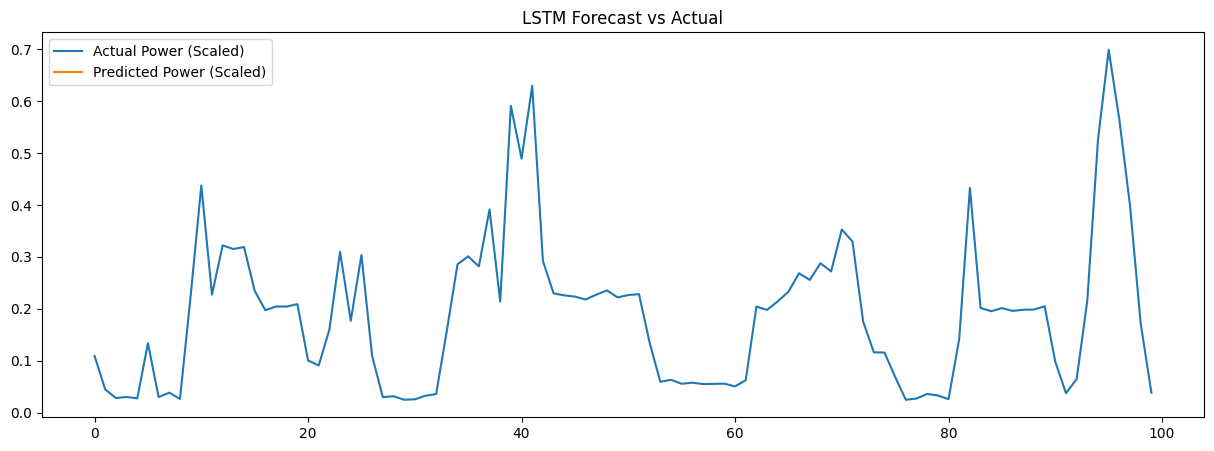

In [4]:
predictions = model.predict(X_test)

# To visualize, we need to inverse the scaling for the target column
# This is a bit tricky since scaler was fit on 4 columns. 
# For now, let's just plot the scaled versions to check the 'shape' fit.
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(y_test[:100], label='Actual Power (Scaled)')
plt.plot(predictions[:100], label='Predicted Power (Scaled)')
plt.legend()
plt.title('LSTM Forecast vs Actual')
plt.show()

In [5]:
# Check the first 5 values of each
print("Actual (first 5):", y_test[:5])
print("Predicted (first 5):", predictions[:5].flatten())

# Check the difference (Mean Absolute Error)
mae = np.mean(np.abs(y_test - predictions.flatten()))
print(f"Mean Absolute Error: {mae}")

Actual (first 5): [0.10966566 0.04509674 0.02857128 0.03069976 0.0279809 ]
Predicted (first 5): [nan nan nan nan nan]
Mean Absolute Error: nan


In [6]:
# Check for any NaNs in the scaled data
print("Any NaNs in scaled_data?", np.isnan(scaled_data).any())

# If True, force fill them (Safety net)
scaled_data = np.nan_to_num(scaled_data)


Any NaNs in scaled_data? True


In [7]:
X, y = create_sequences(scaled_data, 24)

# FINAL CHECK: If these print 'True', the model will fail.
print("NaNs in X:", np.isnan(X).any())
print("NaNs in y:", np.isnan(y).any())

NaNs in X: False
NaNs in y: False


In [8]:
# Force check the dataframe for NaNs
print("Missing values in df before scaling:", df.isnull().sum().sum())

# Fill them definitively
df = df.ffill().bfill() # Forward fill then backward fill to catch everything

# Now scale
data = df[['global_active_power', 'hour', 'day_of_week', 'is_weekend']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Verification - MUST be False
print("Any NaNs in scaled_data now?", np.isnan(scaled_data).any())

Missing values in df before scaling: 3368
Any NaNs in scaled_data now? False


In [11]:
from tensorflow.keras.optimizers import Adam

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

# Use a slightly lower learning rate and add clipping
optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Re-run the fit
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

c:\Users\Subhrank\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 0.0147 - val_loss: 0.0076
Epoch 2/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0103 - val_loss: 0.0071
Epoch 3/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0096 - val_loss: 0.0069
Epoch 4/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0092 - val_loss: 0.0065
Epoch 5/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0088 - val_loss: 0.0062


In [12]:
# Force check the dataframe for NaNs
print("Missing values in df before scaling:", df.isnull().sum().sum())

# Fill them definitively
df = df.ffill().bfill() # Forward fill then backward fill to catch everything

# Now scale
data = df[['global_active_power', 'hour', 'day_of_week', 'is_weekend']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Verification - MUST be False
print("Any NaNs in scaled_data now?", np.isnan(scaled_data).any())

Missing values in df before scaling: 0
Any NaNs in scaled_data now? False


In [13]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Re-split
X, y = create_sequences(scaled_data, 24)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Re-compile with stability features
model.compile(optimizer=Adam(learning_rate=0.001, clipvalue=1.0), loss='mse')

# Add a callback to prevent 'exploding'
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)

history = model.fit(
    X_train, y_train, 
    epochs=5, 
    batch_size=64, # Increased batch size for more stable gradients
    validation_data=(X_test, y_test),
    callbacks=[reduce_lr]
)

Epoch 1/5
433/433 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.0085 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 2/5
433/433 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0084 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 3/5
433/433 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0084 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 4/5
433/433 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0081 - val_loss: 0.0059 - learning_rate: 2.0000e-04
Epoch 5/5
433/433 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0081 - val_loss: 0.0057 - learning_rate: 2.0000e-04


In [14]:
# Train for 5-10 epochs
history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_data=(X_test, y_test),
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0080 - val_loss: 0.0059 - learning_rate: 2.0000e-04
Epoch 2/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0080 - val_loss: 0.0058 - learning_rate: 2.0000e-04
Epoch 3/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0080 - val_loss: 0.0058 - learning_rate: 4.0000e-05
Epoch 4/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0079 - val_loss: 0.0058 - learning_rate: 4.0000e-05
Epoch 5/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0079 - val_loss: 0.0058 - learning_rate: 8.0000e-06
Epoch 6/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0079 - val_loss: 0.0058 - learning_rate: 8.0000e-06
Epoch 7/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0079 - val_loss: 0.0058 - learning_rate: 1.6000e-06
Epoch 8/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0079 - val_loss: 0.0058 - learning_rate: 1.6000e-06
Epoch 9/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0079 - val_loss: 

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


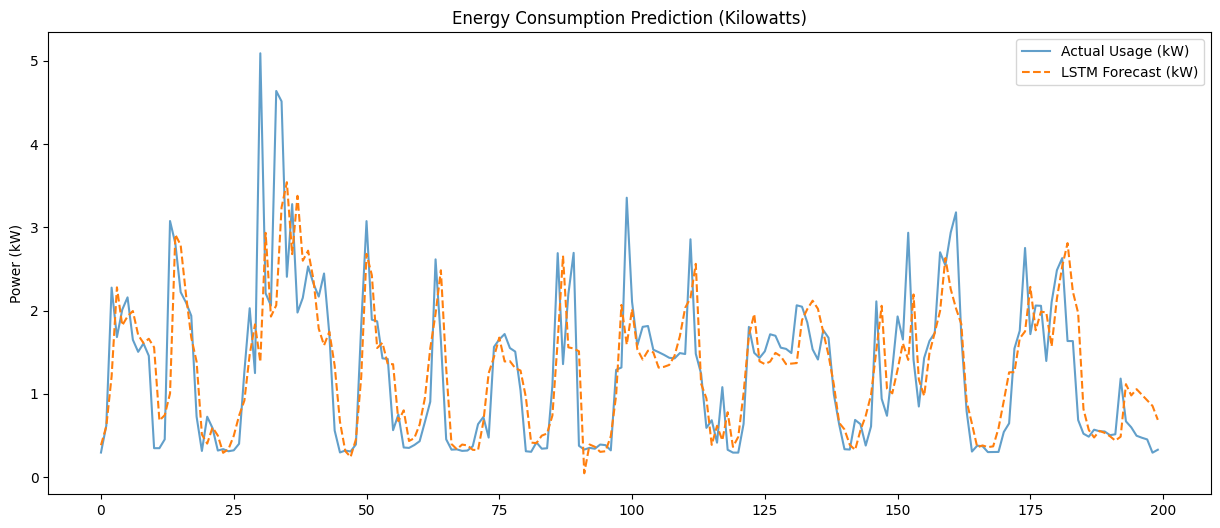

In [15]:
# 1. Get predictions
predictions = model.predict(X_test)

# 2. To inverse scale, we need a 'dummy' array that matches the original 4-column shape
# [global_active_power, hour, day_of_week, is_weekend]
pred_df = np.zeros((len(predictions), 4))
pred_df[:, 0] = predictions.flatten() # Put predictions in the first column
actual_df = np.zeros((len(y_test), 4))
actual_df[:, 0] = y_test # Put actual values in the first column

# 3. Inverse transform
predictions_rescaled = scaler.inverse_transform(pred_df)[:, 0]
y_test_rescaled = scaler.inverse_transform(actual_df)[:, 0]

# 4. Plot
plt.figure(figsize=(15, 6))
plt.plot(y_test_rescaled[200:400], label='Actual Usage (kW)', alpha=0.7)
plt.plot(predictions_rescaled[200:400], label='LSTM Forecast (kW)', linestyle='--')
plt.title('Energy Consumption Prediction (Kilowatts)')
plt.ylabel('Power (kW)')
plt.legend()
plt.show()

In [16]:
# Save the model
model.save('../backend/models/energy_lstm_model.h5')

# Save the scaler (ESSENTIAL for the backend to interpret real data)
import joblib
joblib.dump(scaler, '../backend/models/scaler.pkl')

['../backend/models/scaler.pkl']